<a href="https://colab.research.google.com/github/merinrose4007/DSA-class-activity/blob/main/ETL_CaseStudy_Merin_Rose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load the dataset into a DataFrame


data=pd.read_csv('/content/all_month.csv')

In [ ]:
data

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-09-21T08:52:36.120Z,38.843498,-122.879166,2.310000,1.26,md,15.0,143.00000,0.006242,0.020000,...,2025-09-21T08:54:15.476Z,"13 km E of Cloverdale, CA",earthquake,0.390000,0.460000,0.100000,15.0,automatic,nc,nc
1,2025-09-21T08:50:27.816Z,61.899000,-148.358000,16.400000,1.40,ml,NaN,NaN,NaN,0.850000,...,2025-09-21T08:52:25.893Z,"12 km NNE of Chickaloon, Alaska",earthquake,NaN,0.100000,NaN,NaN,automatic,ak,ak
2,2025-09-21T08:50:02.045Z,35.335915,-97.907661,3.788952,1.88,ml,21.0,56.97023,0.054706,0.879445,...,2025-09-21T08:53:10.972Z,"4 km NE of Minco, Oklahoma",earthquake,2.619322,1.784417,0.320000,15.0,automatic,ok,ok
3,2025-09-21T08:47:27.990Z,38.823334,-122.785500,0.780000,1.08,md,12.0,72.00000,0.010740,0.030000,...,2025-09-21T08:49:05.514Z,"5 km WNW of Cobb, CA",earthquake,0.260000,0.440000,0.180000,12.0,automatic,nc,nc
4,2025-09-21T08:40:23.143Z,60.925200,-151.095000,89.400000,1.70,ml,NaN,NaN,NaN,0.320000,...,2025-09-21T08:41:58.615Z,"16 km S of Tyonek, Alaska",earthquake,NaN,0.900000,NaN,NaN,automatic,ak,ak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,2025-08-22T09:13:13.220Z,37.530500,-113.246333,4.920000,0.52,md,4.0,139.00000,0.094650,0.090000,...,2025-08-22T16:04:25.850Z,"5 km W of Kanarraville, Utah",earthquake,0.730000,3.530000,0.395267,4.0,reviewed,uu,uu
9923,2025-08-22T09:12:06.960Z,58.159000,-155.330667,-0.020000,-0.50,ml,8.0,69.00000,0.051520,0.060000,...,2025-08-23T04:41:57.550Z,"83 km NW of Karluk, Alaska",earthquake,0.180000,2.740000,0.158003,8.0,reviewed,av,av
9924,2025-08-22T09:02:42.241Z,63.015800,-149.777900,69.700000,1.60,ml,NaN,NaN,NaN,0.690000,...,2025-08-22T09:05:13.334Z,"59 km SW of Cantwell, Alaska",earthquake,NaN,0.600000,NaN,NaN,automatic,ak,ak
9925,2025-08-22T08:59:46.950Z,33.229167,-116.744500,9.290000,1.20,ml,70.0,21.00000,0.013750,0.210000,...,2025-08-22T16:00:06.512Z,"2 km SE of Lake Henshaw, CA",earthquake,0.160000,0.400000,0.232000,27.0,reviewed,ci,ci


In [ ]:
#Identify number of records and unique locations
data.shape
data['place'].nunique()

5259

In [ ]:
#Print top 5 rows and column names
data.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-09-21T08:52:36.120Z,38.843498,-122.879166,2.310000,1.26,md,15.0,143.00000,0.006242,0.020000,...,2025-09-21T08:54:15.476Z,"13 km E of Cloverdale, CA",earthquake,0.390000,0.460000,0.10,15.0,automatic,nc,nc
1,2025-09-21T08:50:27.816Z,61.899000,-148.358000,16.400000,1.40,ml,NaN,NaN,NaN,0.850000,...,2025-09-21T08:52:25.893Z,"12 km NNE of Chickaloon, Alaska",earthquake,NaN,0.100000,NaN,NaN,automatic,ak,ak
2,2025-09-21T08:50:02.045Z,35.335915,-97.907661,3.788952,1.88,ml,21.0,56.97023,0.054706,0.879445,...,2025-09-21T08:53:10.972Z,"4 km NE of Minco, Oklahoma",earthquake,2.619322,1.784417,0.32,15.0,automatic,ok,ok
3,2025-09-21T08:47:27.990Z,38.823334,-122.785500,0.780000,1.08,md,12.0,72.00000,0.010740,0.030000,...,2025-09-21T08:49:05.514Z,"5 km WNW of Cobb, CA",earthquake,0.260000,0.440000,0.18,12.0,automatic,nc,nc
4,2025-09-21T08:40:23.143Z,60.925200,-151.095000,89.400000,1.70,ml,NaN,NaN,NaN,0.320000,...,2025-09-21T08:41:58.615Z,"16 km S of Tyonek, Alaska",earthquake,NaN,0.900000,NaN,NaN,automatic,ak,ak


In [ ]:
data.columns.tolist()

['time',
 'latitude',
 'longitude',
 'depth',
 'mag',
 'magType',
 'nst',
 'gap',
 'dmin',
 'rms',
 'net',
 'id',
 'updated',
 'place',
 'type',
 'horizontalError',
 'depthError',
 'magError',
 'magNst',
 'status',
 'locationSource',
 'magSource']

In [ ]:
# Convert time to datetime
data['time']=pd.to_datetime(data['time'], utc= True)

In [ ]:
data['time']

,time
0,2025-09-21 08:52:36.120000+00:00
1,2025-09-21 08:50:27.816000+00:00
2,2025-09-21 08:50:02.045000+00:00
3,2025-09-21 08:47:27.990000+00:00
4,2025-09-21 08:40:23.143000+00:00
...,...
9922,2025-08-22 09:13:13.220000+00:00
9923,2025-08-22 09:12:06.960000+00:00
9924,2025-08-22 09:02:42.241000+00:00
9925,2025-08-22 08:59:46.950000+00:00


In [ ]:
# Drop records with missing latitude, longitude, mag
data = data.dropna(subset=["latitude", "longitude", "mag"])

In [ ]:
#Filter only earthquakes with magnitude >= 4.0
data[data['mag']>=4.0]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
10,2025-09-21 08:17:27.187000+00:00,53.1379,159.7822,60.694,4.6,mb,40.0,113.0,0.693,0.77,...,2025-09-21T08:36:50.040Z,"77 km E of Petropavlovsk-Kamchatsky, Russia",earthquake,5.97,7.218,0.069,62.0,reviewed,us,us
14,2025-09-21 07:34:48.073000+00:00,-13.6169,122.3764,10.000,4.9,mb,33.0,53.0,4.261,0.72,...,2025-09-21T07:51:54.040Z,northwest of Australia,earthquake,7.86,1.890,0.112,25.0,reviewed,us,us
17,2025-09-21 07:14:21.263000+00:00,53.1680,161.2119,10.000,4.6,mb,41.0,113.0,1.552,0.86,...,2025-09-21T07:35:16.040Z,"173 km E of Petropavlovsk-Kamchatsky, Russia",earthquake,6.66,1.835,0.073,56.0,reviewed,us,us
37,2025-09-21 05:24:49.628000+00:00,83.7505,112.2311,10.000,5.1,mb,58.0,75.0,20.771,0.67,...,2025-09-21T05:41:15.040Z,north of Severnaya Zemlya,earthquake,11.87,1.912,0.029,393.0,reviewed,us,us
54,2025-09-21 03:35:08.616000+00:00,52.3500,159.9862,35.000,4.8,mb,39.0,144.0,1.057,0.63,...,2025-09-21T04:01:25.040Z,"121 km SE of Petropavlovsk-Kamchatsky, Russia",earthquake,10.13,1.921,0.074,56.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9884,2025-08-22 11:51:03.015000+00:00,-26.7650,-178.3255,292.157,4.4,mb,43.0,111.0,10.458,0.66,...,2025-08-22T12:27:26.040Z,south of the Fiji Islands,earthquake,12.90,7.219,0.089,36.0,reviewed,us,us
9914,2025-08-22 09:36:12.272000+00:00,-15.3811,-73.6813,93.848,4.4,mb,34.0,142.0,4.366,0.61,...,2025-09-18T10:49:43.040Z,"18 km SW of Incuyo, Peru",earthquake,9.43,10.065,0.114,22.0,reviewed,us,us
9916,2025-08-22 09:33:39.108000+00:00,-30.4607,-177.7927,35.000,5.0,mb,61.0,127.0,7.787,0.88,...,2025-09-18T11:24:45.040Z,"Kermadec Islands, New Zealand",earthquake,11.78,1.874,0.051,124.0,reviewed,us,us
9917,2025-08-22 09:31:00.146000+00:00,39.1358,41.0169,10.000,4.3,mb,27.0,99.0,0.968,0.52,...,2025-09-19T08:39:24.040Z,"17 km S of Karlıova, Turkey",earthquake,4.94,1.939,0.265,4.0,reviewed,us,us


In [ ]:
# Add a column day_of_week from time
data=data.copy()
data.loc[:,"day_of_week"] = data["time"].dt.day_name()

In [ ]:
data

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,day_of_week
0,2025-09-21 08:52:36.120000+00:00,38.843498,-122.879166,2.310000,1.26,md,15.0,143.00000,0.006242,0.020000,...,"13 km E of Cloverdale, CA",earthquake,0.390000,0.460000,0.100000,15.0,automatic,nc,nc,Sunday
1,2025-09-21 08:50:27.816000+00:00,61.899000,-148.358000,16.400000,1.40,ml,NaN,NaN,NaN,0.850000,...,"12 km NNE of Chickaloon, Alaska",earthquake,NaN,0.100000,NaN,NaN,automatic,ak,ak,Sunday
2,2025-09-21 08:50:02.045000+00:00,35.335915,-97.907661,3.788952,1.88,ml,21.0,56.97023,0.054706,0.879445,...,"4 km NE of Minco, Oklahoma",earthquake,2.619322,1.784417,0.320000,15.0,automatic,ok,ok,Sunday
3,2025-09-21 08:47:27.990000+00:00,38.823334,-122.785500,0.780000,1.08,md,12.0,72.00000,0.010740,0.030000,...,"5 km WNW of Cobb, CA",earthquake,0.260000,0.440000,0.180000,12.0,automatic,nc,nc,Sunday
4,2025-09-21 08:40:23.143000+00:00,60.925200,-151.095000,89.400000,1.70,ml,NaN,NaN,NaN,0.320000,...,"16 km S of Tyonek, Alaska",earthquake,NaN,0.900000,NaN,NaN,automatic,ak,ak,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,2025-08-22 09:13:13.220000+00:00,37.530500,-113.246333,4.920000,0.52,md,4.0,139.00000,0.094650,0.090000,...,"5 km W of Kanarraville, Utah",earthquake,0.730000,3.530000,0.395267,4.0,reviewed,uu,uu,Friday
9923,2025-08-22 09:12:06.960000+00:00,58.159000,-155.330667,-0.020000,-0.50,ml,8.0,69.00000,0.051520,0.060000,...,"83 km NW of Karluk, Alaska",earthquake,0.180000,2.740000,0.158003,8.0,reviewed,av,av,Friday
9924,2025-08-22 09:02:42.241000+00:00,63.015800,-149.777900,69.700000,1.60,ml,NaN,NaN,NaN,0.690000,...,"59 km SW of Cantwell, Alaska",earthquake,NaN,0.600000,NaN,NaN,automatic,ak,ak,Friday
9925,2025-08-22 08:59:46.950000+00:00,33.229167,-116.744500,9.290000,1.20,ml,70.0,21.00000,0.013750,0.210000,...,"2 km SE of Lake Henshaw, CA",earthquake,0.160000,0.400000,0.232000,27.0,reviewed,ci,ci,Friday


In [ ]:
#Create a column severity_level based on magnitude:
#○ <4.0: "Low"
#○ 4.0 - 6.0: "Moderate"
#○ 6.0+: "High"
data=data.copy()

data['severity_level'] = np.where(data['mag']<=4.0, 'Low', np.where(data['mag']<6.0, 'Moderate', 'High') )

In [ ]:
#Count number of earthquakes per place
earthquakes = data[data['type'] == 'earthquake']
earthquake_counts = earthquakes['place'].value_counts()
print(earthquake_counts)

place
15 km NE of Milford, Utah                  203
27 km W of Hebgen Lake Estates, Montana     80
7 km NNW of The Geysers, CA                 58
7 km WNW of Cobb, CA                        57
8 km NNW of The Geysers, CA                 51
                                          ... 
2 km SE of Lake Henshaw, CA                  1
46 km WNW of Petrolia, CA                    1
7 km ESE of Willits, CA                      1
17 km NNE of Four Mile Road, Alaska          1
3 km S of Highland, CA                       1
Name: count, Length: 5110, dtype: int64


In [ ]:
earthquake_counts_df = earthquake_counts.reset_index()

In [ ]:
data['day_of_month'].unique()

array([21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,
        4,  3,  2,  1, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22],
      dtype=int32)

In [ ]:
# Compute average magnitude and max depth per day

earthquakes.loc[:,"day_of_month"] = earthquakes["time"].dt.date
a=earthquakes.groupby('day_of_month')['mag'].mean()
print(a)

day_of_month
2025-08-22    1.308744
2025-08-23    1.565403
2025-08-24    1.431208
2025-08-25    1.227680
2025-08-26    1.398613
2025-08-27    1.328432
2025-08-28    1.314414
2025-08-29    1.269650
2025-08-30    1.409890
2025-08-31    1.413304
2025-09-01    1.420166
2025-09-02    1.465817
2025-09-03    1.542601
2025-09-04    1.590893
2025-09-05    1.345403
2025-09-06    1.321763
2025-09-07    1.421466
2025-09-08    1.543754
2025-09-09    1.528251
2025-09-10    1.408300
2025-09-11    1.409358
2025-09-12    1.372584
2025-09-13    1.422199
2025-09-14    1.274072
2025-09-15    1.351809
2025-09-16    1.257674
2025-09-17    1.162997
2025-09-18    1.689659
2025-09-19    1.936068
2025-09-20    2.182697
2025-09-21    1.905647
Name: mag, dtype: float64


/tmp/ipython-input-1912184582.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  earthquakes.loc[:,"day_of_month"] = earthquakes["time"].dt.date


In [ ]:
b=earthquakes.groupby('day_of_month')['depth'].max()
print(b)

day_of_month
2025-08-22    515.056
2025-08-23    565.087
2025-08-24    499.800
2025-08-25    126.766
2025-08-26    612.812
2025-08-27    128.261
2025-08-28    260.716
2025-08-29    541.434
2025-08-30    206.809
2025-08-31    554.091
2025-09-01    210.845
2025-09-02    568.532
2025-09-03    569.035
2025-09-04    392.952
2025-09-05    550.584
2025-09-06    568.998
2025-09-07    334.573
2025-09-08    590.647
2025-09-09    221.643
2025-09-10    259.049
2025-09-11    136.006
2025-09-12    564.825
2025-09-13    563.514
2025-09-14    220.479
2025-09-15    639.511
2025-09-16    585.524
2025-09-17    130.200
2025-09-18    124.428
2025-09-19    279.334
2025-09-20    593.972
2025-09-21    205.600
Name: depth, dtype: float64


In [ ]:
data1 = pd.concat([a, b], axis=1)

In [ ]:
data1.to_csv(' earthquake_summary.csv')

In [ ]:
earthquake_counts_df.to_csv(' earthquake_summary1.csv')

In [ ]:
data.to_csv('cleaned_earthquakes.csv')

In [ ]:
# Store into SQLite table
import sqlite3

conn = sqlite3.connect("earthquakes.db")
earthquake_counts_df.to_sql("earthquake_counts", conn, if_exists="replace", index=False)
data1.to_sql("summary", conn, if_exists="replace", index=False)
data.to_sql("cleaned_data", conn, if_exists="replace", index=False)

9926

In [ ]:
#Create a flowchart of your ETL logic

from graphviz import Digraph

dot = Digraph(comment='Earthquake ETL Flow')

dot.node('A', 'Extract\nLoaded the CSV into a DataFrame')
dot.node('B', 'Transform\n- Convert time to datetime\n- Drop missing lat/lon/mag\n- Add day_of_week\n- Create severity_level')
dot.node('C', 'Load\n Store into SQLite table')

# Edges
dot.edge('A', 'B', label='Data cleaning & transformation')
dot.edge('B', 'C', label='Store processed data')

# Render and display
dot.render('etl_flowchart', view=True)


'etl_flowchart.pdf'

# A short explanation of your process


* We began by loading the CSV file into a dataframe. The file
contain columns like time, place, latitude, longitude, magnitude, type etc.
* Cleaned the dataset by removing the missing values in longitude, latitude and magnitude.
* Converted time to pandas datetime objects.
* We feature extratced 2 features:


* day_of_week from time - the weekday name of the earthquake.
* severity_level from magnitude - classify earthquakes as Low (<4.0), Moderate (4.0–6.0), High (>6.0) based on magnitude.


* Stored the cleaned and transformed dataset into a SQLite database table.

In [ ]:
correlation = data['mag'].corr(data['rms'])
print("Correlation between magnitude and RMS:", correlation)

Correlation between magnitude and RMS: 0.6686972734264254


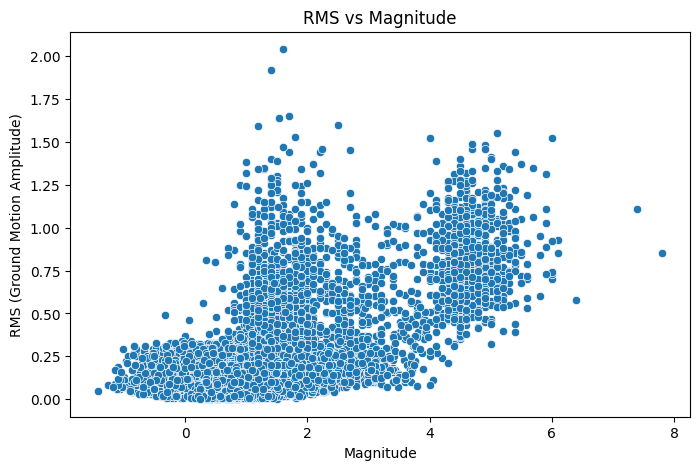

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x='mag', y='rms', data=data)
plt.xlabel('Magnitude')
plt.ylabel('RMS (Ground Motion Amplitude)')
plt.title('RMS vs Magnitude')
plt.show()


#One insight your team discovered from the data
rms measures the average amplitude of the seismic waves(information collected about the earth’s movements) The above scattered plot and correlation between rms and magnitude gives as the insight higher magnitude earthquakes have higher rms values. Hence RMS value is helpful for early detction of earthquakes